In [4]:
pip install --pre pycen==0.1.0a4

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pycen
import numpy as np
import matplotlib.pyplot as plt
from pycen import explore, acquire
import geopandas as gpd
import pandas as pd

In [6]:
explore.browse(year=2013, dataset='acs5').show()

In [7]:
vars_to_download = {
    "B08301_018E": "bikers",
    "B08301_001E": "workers_total",
    "B01003_001E": "total_pop"}

PLACE = "Concord"
YEARS = [2014, 2015, 2016, 2017, 2018, 2019]
DATASET = "acs5"

In [100]:
gdf = acquire.get_censhp(
      variables=vars_to_download,
      geography='tract',
      state='CA',
      place='Concord',
      year=2014,
      dataset='acs5',
      add_area=True,               # calculate area and adds to geodataframe
      cache=False                # cache by default, can disable
      #cache_dir="./pycen_cache"  # default cache directo"ry, can customize
  )
gdf.head()
gdf=gdf.sort_values(by='tract')
gdf=gdf.set_index('tract')

Resolving geography...
  State: California (CA, FIPS: 06)

Fetching data...
  Product: acs5 (2014)
  Geography: Tract
  Variables: 3


Downloading: 100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


Fetching boundaries...
Merging data...
Clipping to place: Concord
Fetching boundaries...

Done!


In [101]:
gdf["pctbikers"]=gdf["bikers"]/gdf["workers_total"]*100
#print(gdf)

In [102]:
ninet = acquire.get_censhp(
      variables=vars_to_download,
      geography='tract',
      state='CA',
      place='Concord',
      year=2019,
      dataset='acs5',
      add_area=True,               # calculate area and adds to geodataframe
      cache=False                # cache by default, can disable
      #cache_dir="./pycen_cache"  # default cache directory, can customize
  )
ninet.head()
ninet=ninet.sort_values(by='tract')
ninet=ninet.set_index('tract')

Resolving geography...
  State: California (CA, FIPS: 06)

Fetching data...
  Product: acs5 (2019)
  Geography: Tract
  Variables: 3


Downloading: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


Fetching boundaries...
Merging data...
Clipping to place: Concord
Fetching boundaries...

Done!


In [103]:
ninet["pctbikers"]=ninet["bikers"]/ninet["workers_total"]*100
#print(ninet)

In [104]:
change=ninet.copy()
print(ninet["pctbikers"]-gdf["pctbikers"])
change["Change in % Bike Commuters between 2014-2019"]=(ninet["pctbikers"]-gdf["pctbikers"])
#print(ninet["pctbikers"])
#print(gdf["pctbikers"])
#print(ninet["pctbikers"]-gdf["pctbikers"])
#print(change)
#print(gdf.loc['981900'])
#print(ninet.loc['981900'])
#print(change.loc['981900'])

tract
328000   -1.084599
329000   -0.876926
330000   -0.446453
331000    0.360410
332000   -0.397220
333101   -1.569054
333102    0.454959
333200    2.169349
334001   -0.658522
334004   -1.168091
334006    0.140119
335000    2.482270
336101   -0.915311
336102   -1.567310
336201   -0.117333
336202   -0.267482
337100    0.000000
337200   -1.400400
338101   -0.906056
338102   -1.077708
355200    0.000000
355301    0.000000
Name: pctbikers, dtype: float64


In [92]:
#CHANGE IN RIDERSHIP set (indexted by census tract)
#change["% Change in Ridership between 2013-2019"]

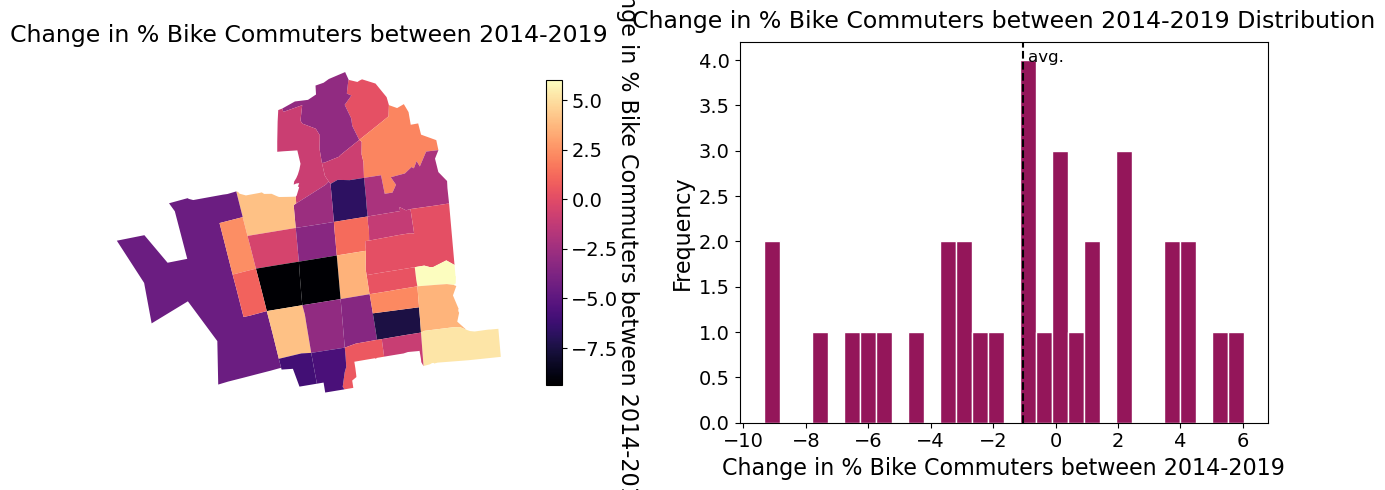

In [93]:
acquire.quick_viz(change, "Change in % Bike Commuters between 2014-2019")

In [105]:
highextreme=change[change["Change in % Bike Commuters between 2014-2019"]>2]
#print(highextreme)
highextremearray=highextreme.index.values.astype(int)
print(highextremearray)

[333200 335000]


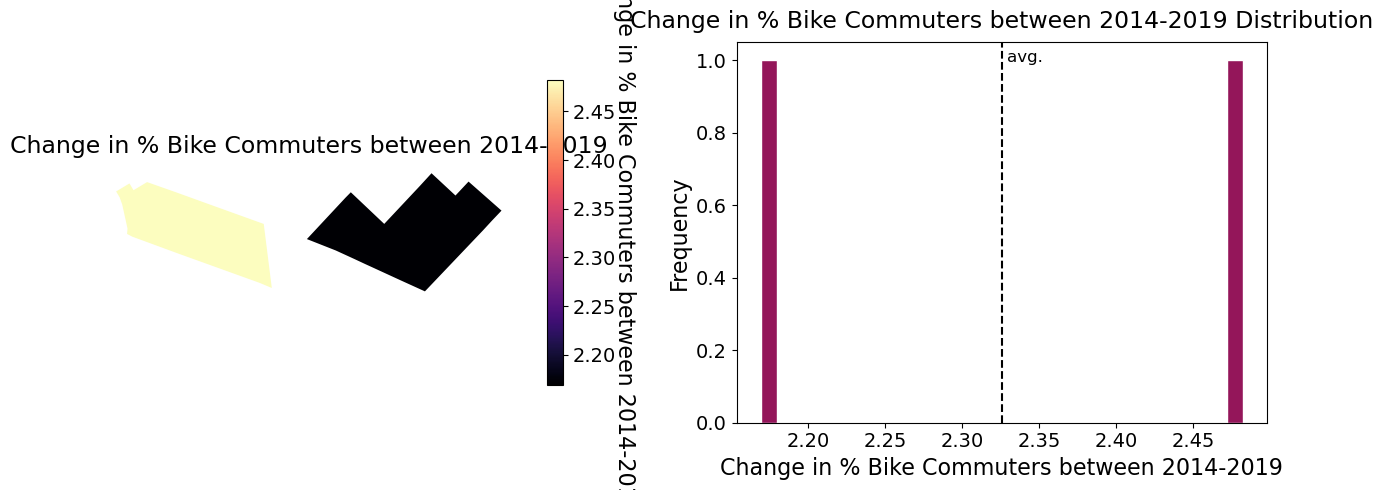

In [106]:
acquire.quick_viz(highextreme, "Change in % Bike Commuters between 2014-2019")

In [95]:
tracts_by_year=[]
for year in YEARS:
    gdf1 = acquire.get_censhp(
        variables=vars_to_download,
        geography="tract",
        place='Berkeley',
        state="CA",
        year=year,
        dataset=DATASET,
        add_area=True
    )
    gdf1.replace(-666666666, np.nan, inplace=True) 
    gdf1["year"] = year
    gdf1["pct_bike"] = (gdf1["bikers"] / gdf1["workers_total"]) * 100
    highextremetracts = gdf1[gdf1["tract"].isin(highextremearray)]
    tracts_by_year.append(highextremetracts.to_crs("EPSG:4326"))

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__5bf4e91799de9b6e.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2015_tract_06__c986042f4b8c1bba.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2016_tract_06__3b2f7071f994cad5.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2017_tract_06__fccb75340177cf0e.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Lo

In [96]:
tracts = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")
print(tracts[["tract", "pct_bike", "year"]].groupby("tract").head())

     tract   pct_bike  year
0   422700   0.231303  2014
1   423602   3.599504  2014
2   421900   6.202290  2014
3   422900   4.734411  2014
4   421500   1.204188  2014
5   423300   7.808433  2014
6   422100   8.834447  2014
7   423800   4.188097  2014
8   423700   5.686275  2014
9   422900   5.575266  2015
10  421500   1.485411  2015
11  422100   7.544484  2015
12  423602   5.029155  2015
13  421900   8.155147  2015
14  422700   3.400576  2015
15  423800   4.442877  2015
16  423300   6.882169  2015
17  423700   8.145065  2015
18  422900  10.741365  2016
19  423602   4.030781  2016
20  422100   8.404908  2016
21  423800   4.437870  2016
22  421900   8.541267  2016
23  421500   0.993724  2016
24  423300   8.769307  2016
25  423700   6.800710  2016
26  422700   4.090194  2016
27  422900   8.855799  2017
28  422100  10.562500  2017
29  422700   5.099563  2017
30  423800   4.329004  2017
31  421500   2.394294  2017
32  423300   9.394904  2017
33  423700   8.895028  2017
34  423602   4.61422

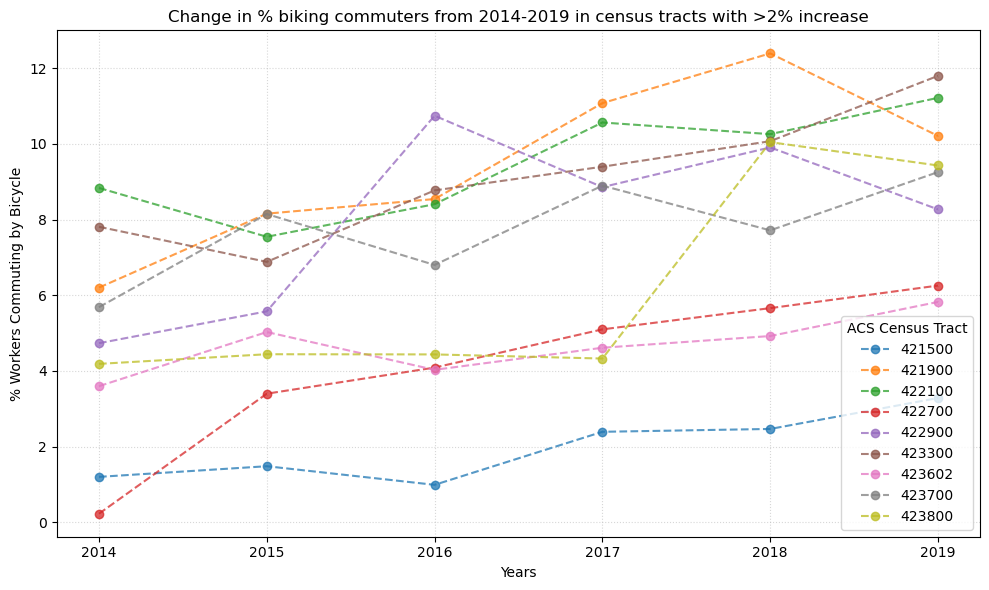

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))
for tract, group in tracts.groupby("tract"):
    group = group.dropna(subset=["year", "pct_bike"])
    ax.plot(
        YEARS,
        group["pct_bike"],
        alpha=0.75,
        label=tract,
        linestyle='--', 
        marker='o'
    )
ax.set_xlabel("Years")
ax.set_ylabel("% Workers Commuting by Bicycle")
ax.set_title("Change in % biking commuters from 2014-2019 in census tracts with >2% increase")
ax.legend(title="ACS Census Tract")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()